# Inference Exchange — Analytical Foundation

**Purpose**: Define the consumer decision problem, build the cost model,
compute quality-price frontiers, and identify which dimensions actually
matter for routing. This analysis determines what the Exchange page should
show — UI is derived from this, not the other way around.

## The decision problem

A consumer wants to run inference. They have:
- A **task type** (chat, code, RAG, agent) that implies a quality floor
- A **workload shape** (input tokens, output tokens, cache hit rate)
- A **budget** (max $/request or $/month)

They need to choose a **model + provider** combination that minimizes cost
subject to their quality floor. Or equivalently: maximizes quality subject
to their budget.

The Exchange page should answer: *given my workload and quality needs,
what are my options and what do they actually cost?*


## 1. Full data pull — every pricing dimension and benchmark

In [1]:
import httpx, json, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats as sp_stats

plt.rcParams.update({
    "figure.facecolor": "#0e0e0e", "axes.facecolor": "#141414",
    "axes.edgecolor": "#333", "axes.labelcolor": "#ccc",
    "text.color": "#ccc", "xtick.color": "#999", "ytick.color": "#999",
    "grid.color": "#222", "legend.facecolor": "#1a1a1a",
    "legend.edgecolor": "#333", "figure.dpi": 120,
})

print("Pulling full OpenRouter model catalog...")
resp = httpx.get("https://openrouter.ai/api/v1/models", timeout=30)
raw = resp.json()["data"]
print(f"  {len(raw)} total models returned")

# Extract ALL pricing dimensions + benchmarks + metadata
rows = []
for m in raw:
    p = m.get("pricing") or {}
    inp = float(p.get("prompt", "0") or "0")
    out = float(p.get("completion", "0") or "0")
    if inp <= 0 and out <= 0:
        continue

    cache_r = float(p.get("input_cache_read", "0") or "0")
    cache_w = float(p.get("input_cache_write", "0") or "0")
    image   = float(p.get("image", "0") or "0")
    reason  = float(p.get("internal_reasoning", "0") or "0")
    websrch = float(p.get("web_search", "0") or "0")

    bench = m.get("benchmarks") or {}
    aa = bench.get("artificial_analysis") or {}

    arch = m.get("architecture") or {}

    rows.append({
        "model_id":      m["id"],
        "name":          m.get("name", m["id"]),
        "vendor":        m["id"].split("/")[0].strip("~"),
        "context":       m.get("context_length", 0),
        "modality":      arch.get("modality", ""),
        # Pricing (per token — we'll convert to $/Mtok below)
        "p_input":       inp,
        "p_output":      out,
        "p_cache_read":  cache_r,
        "p_cache_write": cache_w,
        "p_image":       image,
        "p_reasoning":   reason,
        "p_websearch":   websrch,
        # Benchmarks
        "intel_idx":     aa.get("intelligence_index"),
        "coding_idx":    aa.get("coding_index"),
        "agentic_idx":   aa.get("agentic_index"),
    })

df = pd.DataFrame(rows)

# Convert per-token to $/Mtok
for col in ["p_input", "p_output", "p_cache_read", "p_cache_write", "p_image", "p_reasoning"]:
    df[f"{col}_mtok"] = df[col] * 1_000_000

# Derived columns
df["has_cache"]    = df["p_cache_read"] > 0
df["has_bench"]    = df["intel_idx"].notna()
df["cache_disc"]   = np.where(df["p_input"] > 0, 1 - df["p_cache_read"] / df["p_input"], 0)
df["io_ratio"]     = np.where(df["p_input"] > 0, df["p_output"] / df["p_input"], 0)

print(f"  {len(df)} models with pricing")
print(f"  {df['has_cache'].sum()} with cache read pricing ({df['has_cache'].mean():.0%})")
print(f"  {df['has_bench'].sum()} with intelligence index ({df['has_bench'].mean():.0%})")
print(f"  {(df['p_cache_write'] > 0).sum()} with cache write pricing")
print(f"  {(df['p_reasoning'] > 0).sum()} with reasoning token pricing")
print(f"  {(df['p_websearch'] > 0).sum()} with web search pricing")
print(f"  {df['vendor'].nunique()} unique vendors")


Pulling full OpenRouter model catalog...


  464 total models returned
  438 models with pricing
  300 with cache read pricing (68%)
  136 with intelligence index (31%)
  96 with cache write pricing
  31 with reasoning token pricing
  179 with web search pricing
  52 unique vendors


## 2. The cost model

The cost of a single inference request is:

$$
C = \frac{I_{fresh}}{10^6} \cdot p_{in} + \frac{I_{cached}}{10^6} \cdot p_{cache} + \frac{O}{10^6} \cdot p_{out}
$$

Where:
- $I_{fresh} = I_{total} \cdot (1 - h)$ = fresh input tokens
- $I_{cached} = I_{total} \cdot h$ = cached input tokens
- $h$ = cache hit rate (0 to 1)
- $O$ = output tokens
- $p_{cache}$ = cache read price (falls back to $p_{in}$ if no cache pricing)

For models with reasoning token pricing (Gemini), there's an additional term
for thinking tokens. For models with web search, there's a per-query charge.
We'll handle those as separate cost components.


In [2]:
def request_cost(row, input_tok, output_tok, cache_rate, reasoning_tok=0):
    """Cost of a single request in USD given a model's pricing row."""
    cache_price = row["p_cache_read"] if row["p_cache_read"] > 0 else row["p_input"]
    fresh = input_tok * (1 - cache_rate)
    cached = input_tok * cache_rate

    c_input  = fresh * row["p_input"]
    c_cache  = cached * cache_price
    c_output = output_tok * row["p_output"]
    c_reason = reasoning_tok * row["p_reasoning"]

    return c_input + c_cache + c_output + c_reason

# Verify: Claude Sonnet 4.6 at 2K input, 80% cache, 500 output
claude = df[df["model_id"] == "anthropic/claude-sonnet-4.6"].iloc[0]
test_cost = request_cost(claude, 2000, 500, 0.8)
print(f"Claude Sonnet 4.6 @ 2K in / 80% cache / 500 out = ${test_cost:.6f}")
print(f"  vs no cache: ${request_cost(claude, 2000, 500, 0.0):.6f}")
print(f"  cache saves: {(1 - test_cost / request_cost(claude, 2000, 500, 0.0)):.0%}")


Claude Sonnet 4.6 @ 2K in / 80% cache / 500 out = $0.009180
  vs no cache: $0.013500
  cache saves: 32%


## 3. Representative workload profiles

Rather than a single "2K input, 500 output" assumption, define profiles that
represent how people actually use inference. These come from typical usage patterns.


In [3]:
WORKLOADS = {
    "Chatbot": {
        "desc": "Multi-turn conversation. High cache (system prompt + history reused).",
        "input_tok": 2000, "output_tok": 400, "cache_rate": 0.75,
        "quality_floor": "intel",  # needs decent general intelligence
    },
    "Code assistant": {
        "desc": "Code generation with file context. Moderate cache (file context stable).",
        "input_tok": 4000, "output_tok": 800, "cache_rate": 0.60,
        "quality_floor": "coding",  # needs strong coding ability
    },
    "RAG pipeline": {
        "desc": "Retrieval + synthesis. Low cache (different docs each query).",
        "input_tok": 6000, "output_tok": 300, "cache_rate": 0.20,
        "quality_floor": "intel",
    },
    "Agent loop": {
        "desc": "Tool-calling agent. Very high cache (long system prompt reused).",
        "input_tok": 3000, "output_tok": 200, "cache_rate": 0.85,
        "quality_floor": "agentic",
    },
}

# Compute cost for every model under every workload
cost_records = []
for wl_name, wl in WORKLOADS.items():
    for _, row in df.iterrows():
        c = request_cost(row, wl["input_tok"], wl["output_tok"], wl["cache_rate"])
        c_nocache = request_cost(row, wl["input_tok"], wl["output_tok"], 0.0)
        cost_records.append({
            "model_id":    row["model_id"],
            "name":        row["name"],
            "vendor":      row["vendor"],
            "workload":    wl_name,
            "cost":        c,
            "cost_nocache": c_nocache,
            "cache_saving": 1 - c / c_nocache if c_nocache > 0 else 0,
            "intel_idx":   row["intel_idx"],
            "coding_idx":  row["coding_idx"],
            "agentic_idx": row["agentic_idx"],
            "has_cache":   row["has_cache"],
            "context":     row["context"],
            "p_output_mtok": row["p_output_mtok"],
        })

costs = pd.DataFrame(cost_records)

# Summary: cheapest model per workload
print("Cheapest model per workload:")
print("=" * 80)
for wl_name in WORKLOADS:
    sub = costs[costs["workload"] == wl_name].sort_values("cost")
    top = sub.head(5)
    print(f"\n{wl_name} ({WORKLOADS[wl_name]['desc']})")
    print(f"  {'Model':<40} {'Cost/req':>10} {'Cache saves':>12} {'Intel':>6}")
    print(f"  {'-'*40} {'-'*10} {'-'*12} {'-'*6}")
    for _, r in top.iterrows():
        intel = f"{r['intel_idx']:.1f}" if pd.notna(r["intel_idx"]) else "—"
        print(f"  {r['name'][:40]:<40} ${r['cost']:.6f}  {r['cache_saving']:>10.0%}  {intel:>6}")


Cheapest model per workload:

Chatbot (Multi-turn conversation. High cache (system prompt + history reused).)
  Model                                      Cost/req  Cache saves  Intel
  ---------------------------------------- ---------- ------------ ------
  inclusionAI: Ling 3.0 Flash VL           $0.000041         38%    24.6
  inclusionAI: Ling 3.0 Flash              $0.000042         37%    20.1
  Mistral: Mistral Nemo                    $0.000050          0%       —
  Nex AGI: Nex-N2.5-Mini                   $0.000056         38%       —
  OpenAI: gpt-oss-20b                      $0.000058         19%     9.0

Code assistant (Code generation with file context. Moderate cache (file context stable).)
  Model                                      Cost/req  Cache saves  Intel
  ---------------------------------------- ---------- ------------ ------
  inclusionAI: Ling 3.0 Flash VL           $0.000093         30%    24.6
  inclusionAI: Ling 3.0 Flash              $0.000094         30% 

## 4. Quality-price Pareto frontier

The key analytical artifact: for each workload, find the models where no other
model is both cheaper AND higher quality. This is the "efficient frontier" —
the set of rational choices. Everything else is dominated.


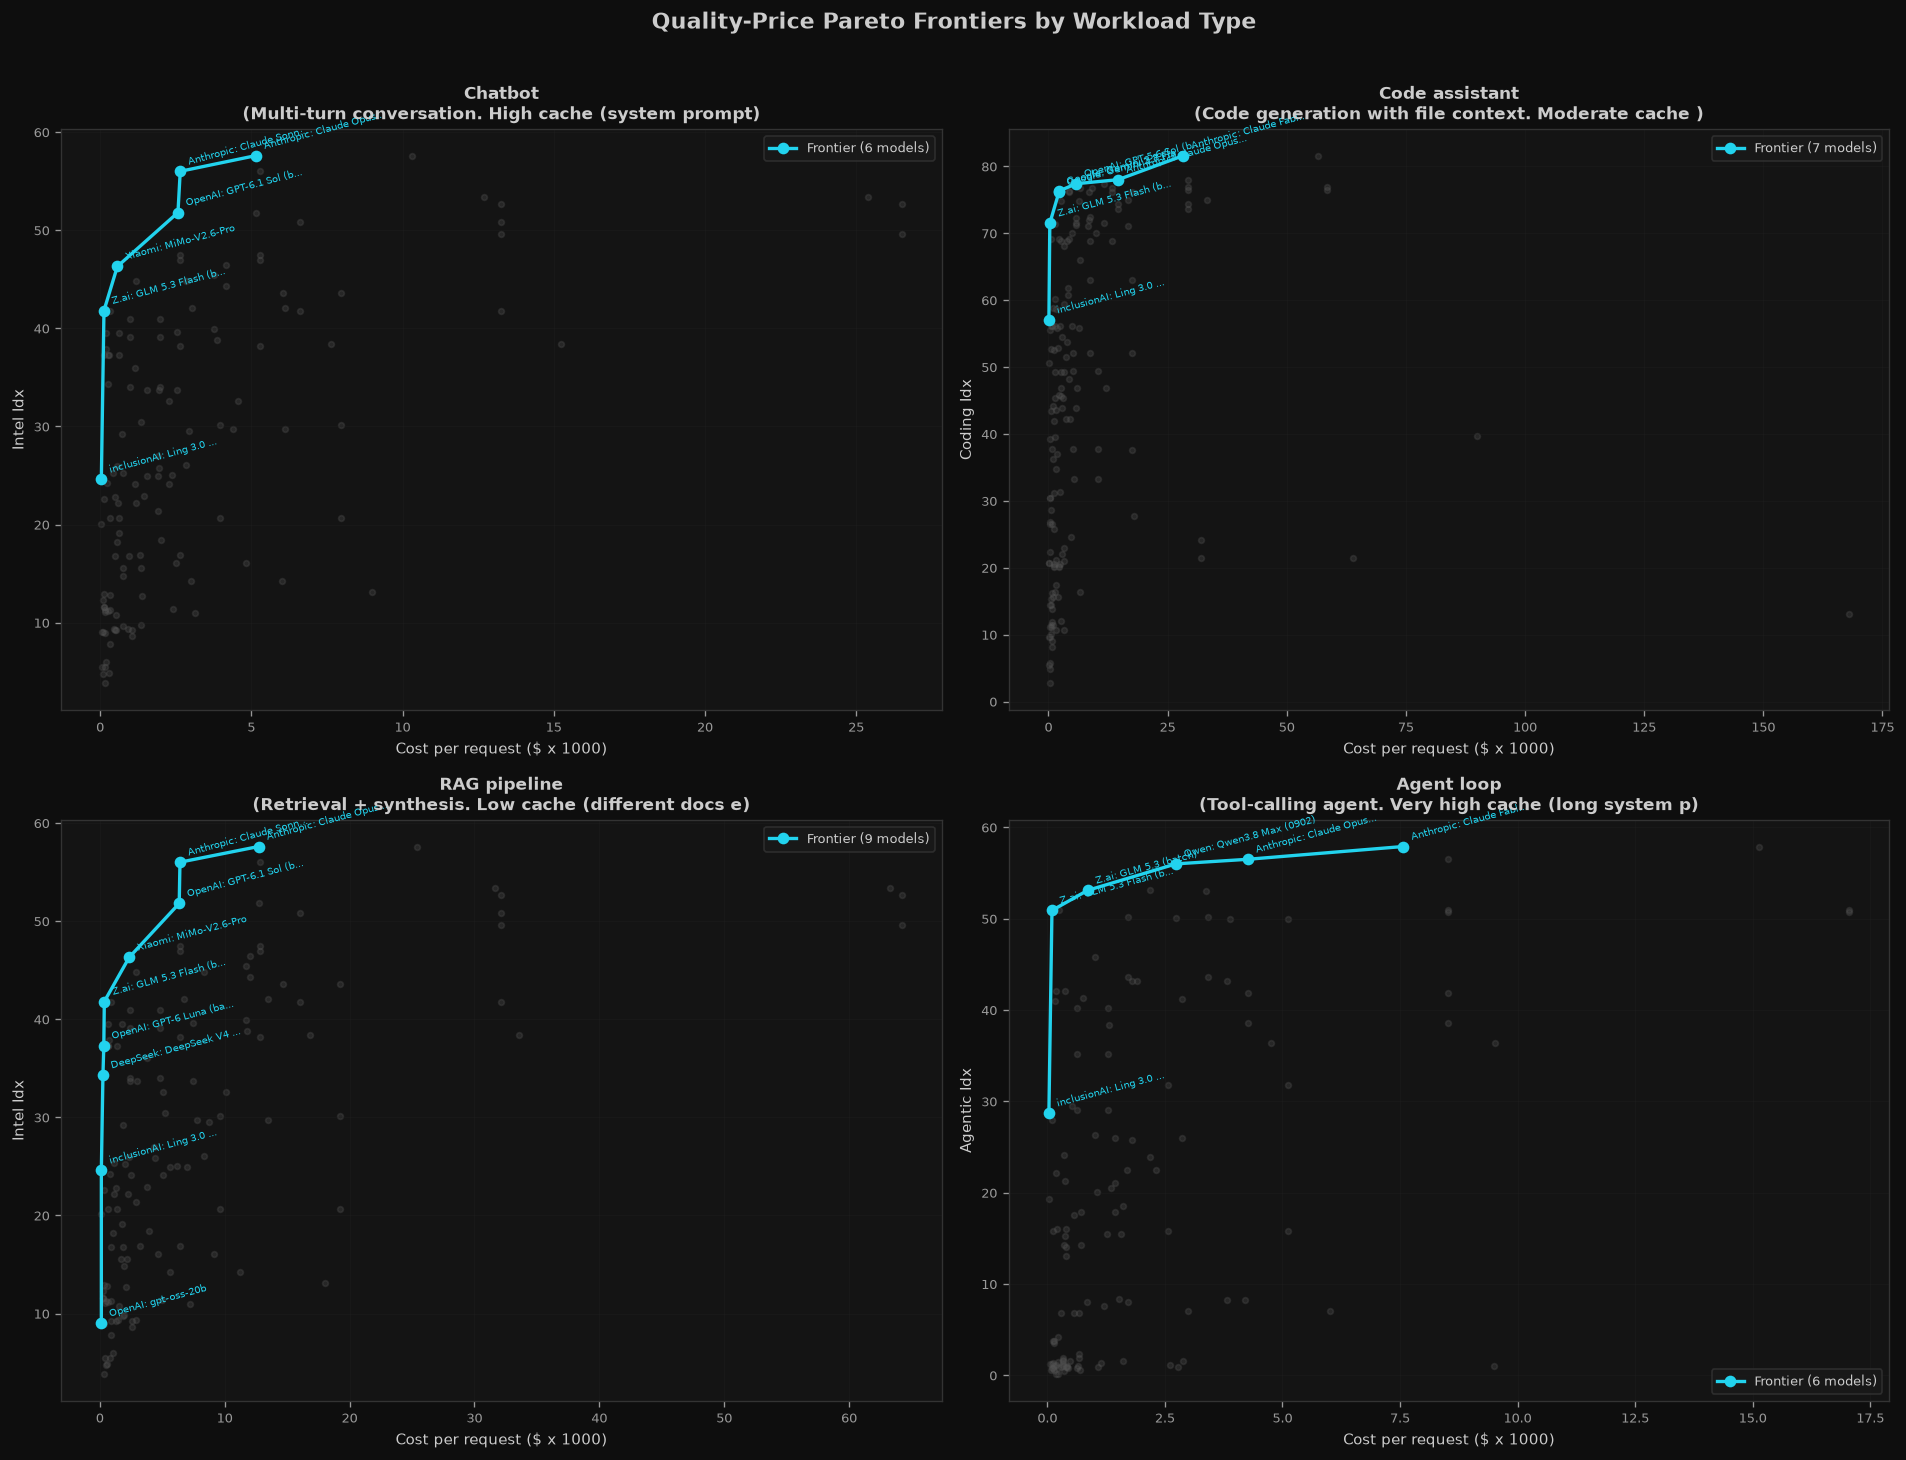


Chatbot frontier (intel_idx):
  inclusionAI: Ling 3.0 Flash VL           cost=$0.000041  intel_idx=24.6  cache_save=38%
  Z.ai: GLM 5.3 Flash (batch)              cost=$0.000128  intel_idx=41.8  cache_save=36%
  Xiaomi: MiMo-V2.6-Pro                    cost=$0.000571  intel_idx=46.3  cache_save=53%
  OpenAI: GPT-6.1 Sol (batch)              cost=$0.002575  intel_idx=51.8  cache_save=36%
  Anthropic: Claude Sonnet 5.5 (batch)     cost=$0.002650  intel_idx=56.0  cache_save=34%
  Anthropic: Claude Opus 5.5 (batch)       cost=$0.005150  intel_idx=57.6  cache_save=36%

Code assistant frontier (coding_idx):
  inclusionAI: Ling 3.0 Flash VL           cost=$0.000093  coding_idx=57.0  cache_save=30%
  Z.ai: GLM 5.3 Flash (batch)              cost=$0.000285  coding_idx=71.5  cache_save=29%
  Google: Gemini 3.7 Flash (batch)         cost=$0.002190  coding_idx=76.1  cache_save=27%
  Google: Gemini 3.8 Flash (batch)         cost=$0.002190  coding_idx=76.3  cache_save=27%
  OpenAI: GPT-5.6 Sol (bat

In [4]:
def pareto_frontier(df_sub, cost_col="cost", quality_col="intel_idx"):
    """Find Pareto-optimal rows (minimize cost, maximize quality)."""
    valid = df_sub.dropna(subset=[quality_col]).copy()
    if len(valid) == 0:
        return pd.DataFrame()
    valid = valid.sort_values(cost_col)
    frontier = []
    max_quality = -np.inf
    for _, row in valid.iterrows():
        if row[quality_col] > max_quality:
            frontier.append(row)
            max_quality = row[quality_col]
    return pd.DataFrame(frontier)

# Compute frontiers for each workload
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, (wl_name, wl) in enumerate(WORKLOADS.items()):
    ax = axes[i // 2][i % 2]
    sub = costs[costs["workload"] == wl_name].copy()

    # Quality column for this workload
    qcol = {"intel": "intel_idx", "coding": "coding_idx", "agentic": "agentic_idx"}[wl["quality_floor"]]

    # All models with quality data
    has_q = sub.dropna(subset=[qcol])

    if len(has_q) == 0:
        ax.text(0.5, 0.5, f"No {qcol} data", transform=ax.transAxes, ha="center", color="#666")
        ax.set_title(wl_name, fontsize=11, fontweight="bold")
        continue

    # Plot all models
    ax.scatter(has_q["cost"] * 1000, has_q[qcol], s=12, alpha=0.3, color="#555", zorder=1)

    # Pareto frontier
    front = pareto_frontier(has_q, "cost", qcol)
    if len(front) > 0:
        ax.plot(front["cost"] * 1000, front[qcol], "o-", color="#22d3ee",
                linewidth=2, markersize=6, zorder=3, label=f"Frontier ({len(front)} models)")

        # Label frontier models
        for _, r in front.iterrows():
            label = r["name"]
            if len(label) > 25: label = label[:22] + "..."
            ax.annotate(label, (r["cost"] * 1000, r[qcol]),
                        fontsize=6, color="#22d3ee", rotation=15,
                        xytext=(4, 4), textcoords="offset points")

    ax.set_xlabel("Cost per request ($ x 1000)", fontsize=9)
    ax.set_ylabel(f"{qcol.replace('_', ' ').title()}", fontsize=9)
    ax.set_title(f"{wl_name}\n({wl['desc'][:50]})", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

fig.suptitle("Quality-Price Pareto Frontiers by Workload Type",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Print frontier models
for wl_name, wl in WORKLOADS.items():
    qcol = {"intel": "intel_idx", "coding": "coding_idx", "agentic": "agentic_idx"}[wl["quality_floor"]]
    sub = costs[costs["workload"] == wl_name]
    front = pareto_frontier(sub, "cost", qcol)
    print(f"\n{wl_name} frontier ({qcol}):")
    if len(front) > 0:
        for _, r in front.iterrows():
            print(f"  {r['name'][:40]:<40} cost=${r['cost']:.6f}  {qcol}={r[qcol]:.1f}  cache_save={r['cache_saving']:.0%}")
    else:
        print(f"  No models with {qcol} data")


## 5. Sensitivity analysis — which pricing dimension matters most?

For each workload, how much does total cost change when we vary one dimension
while holding others fixed? This tells us which columns the Exchange page
*must* show prominently vs which are secondary.


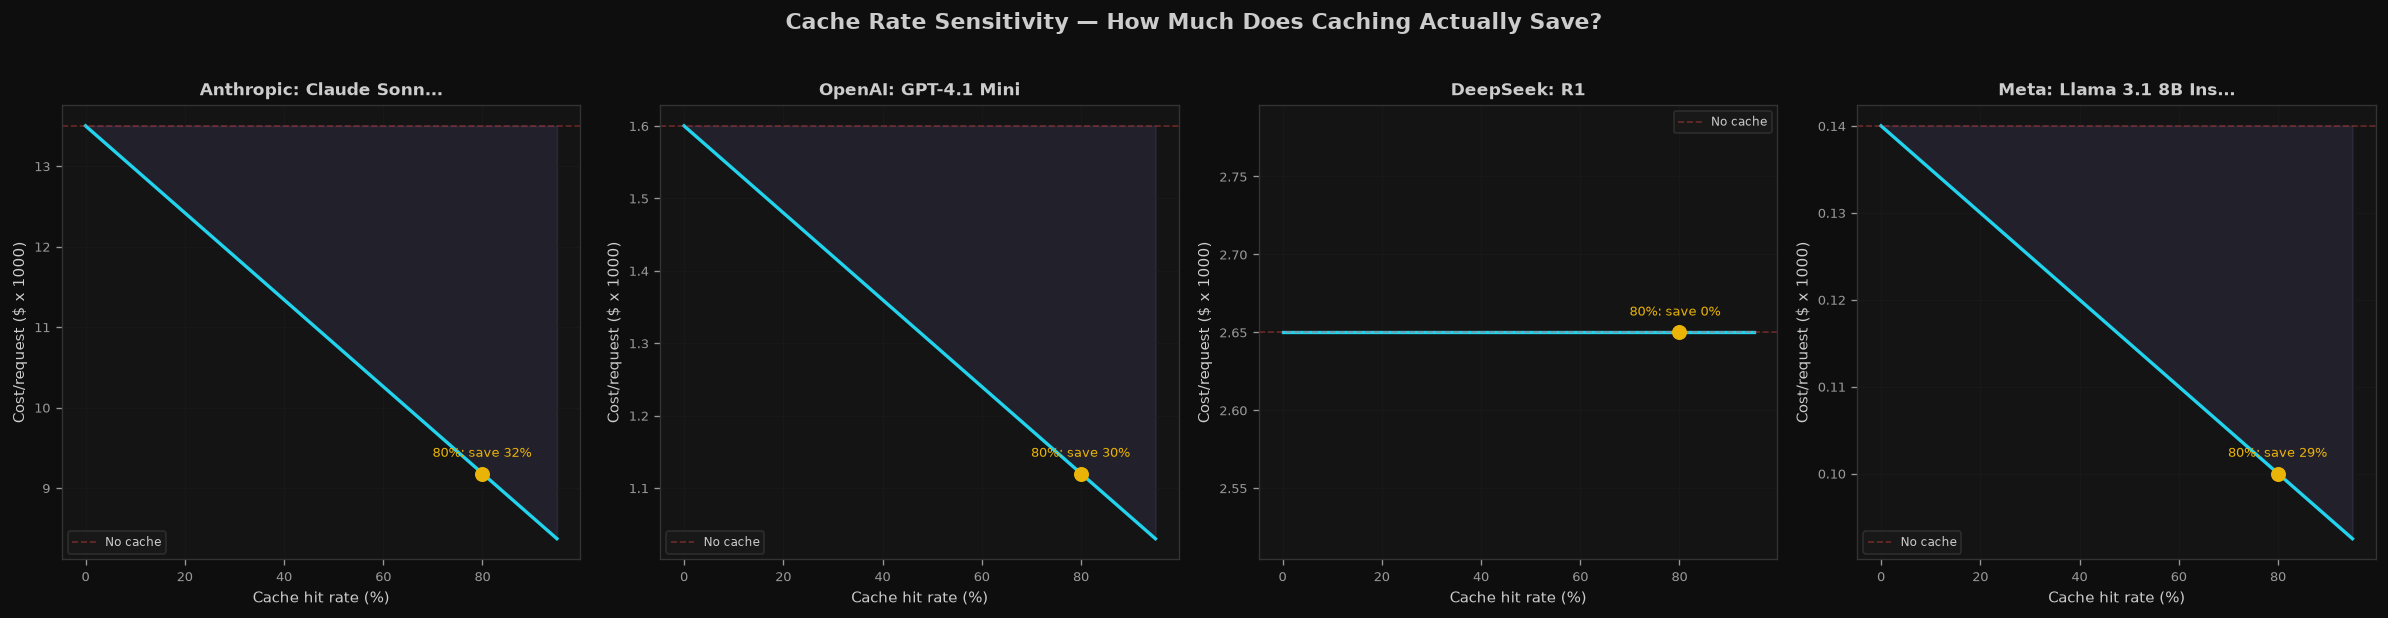

In [5]:
# Pick a representative model from each tier
test_models = df[df["model_id"].isin([
    "anthropic/claude-sonnet-4.6",
    "openai/gpt-4.1-mini",
    "deepseek/deepseek-r1",
    "meta-llama/llama-3.1-8b-instruct",
])].copy()

if len(test_models) == 0:
    # Fallback: pick by name fragment
    for frag in ["claude-sonnet-4", "gpt-4.1-mini", "deepseek-r1", "llama-3.1-8b"]:
        match = df[df["model_id"].str.contains(frag, case=False)]
        if len(match) > 0:
            test_models = pd.concat([test_models, match.head(1)])

# Sensitivity: vary cache rate from 0% to 95%
cache_rates = np.arange(0, 1.0, 0.05)
base_in, base_out = 2000, 500

fig, axes = plt.subplots(1, len(test_models), figsize=(5 * len(test_models), 5), squeeze=False)
axes = axes.flatten()

for i, (_, model) in enumerate(test_models.iterrows()):
    ax = axes[i]
    costs_by_cache = [request_cost(model, base_in, base_out, cr) for cr in cache_rates]
    no_cache_cost = request_cost(model, base_in, base_out, 0.0)

    ax.plot(cache_rates * 100, np.array(costs_by_cache) * 1000, color="#22d3ee", linewidth=2)
    ax.axhline(no_cache_cost * 1000, color="#ef4444", linestyle="--", alpha=0.4, linewidth=1, label="No cache")
    ax.fill_between(cache_rates * 100, np.array(costs_by_cache) * 1000,
                    no_cache_cost * 1000, alpha=0.1, color="#a78bfa")

    # Mark 80% cache
    cost_80 = request_cost(model, base_in, base_out, 0.80)
    saving_80 = (1 - cost_80 / no_cache_cost) * 100
    ax.plot(80, cost_80 * 1000, "o", color="#eab308", markersize=8, zorder=5)
    ax.annotate(f"80%: save {saving_80:.0f}%", (80, cost_80 * 1000),
                fontsize=8, color="#eab308", xytext=(-30, 10), textcoords="offset points")

    short_name = model["name"]
    if len(short_name) > 25: short_name = short_name[:22] + "..."
    ax.set_title(short_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Cache hit rate (%)", fontsize=9)
    ax.set_ylabel("Cost/request ($ x 1000)", fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

fig.suptitle("Cache Rate Sensitivity — How Much Does Caching Actually Save?",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


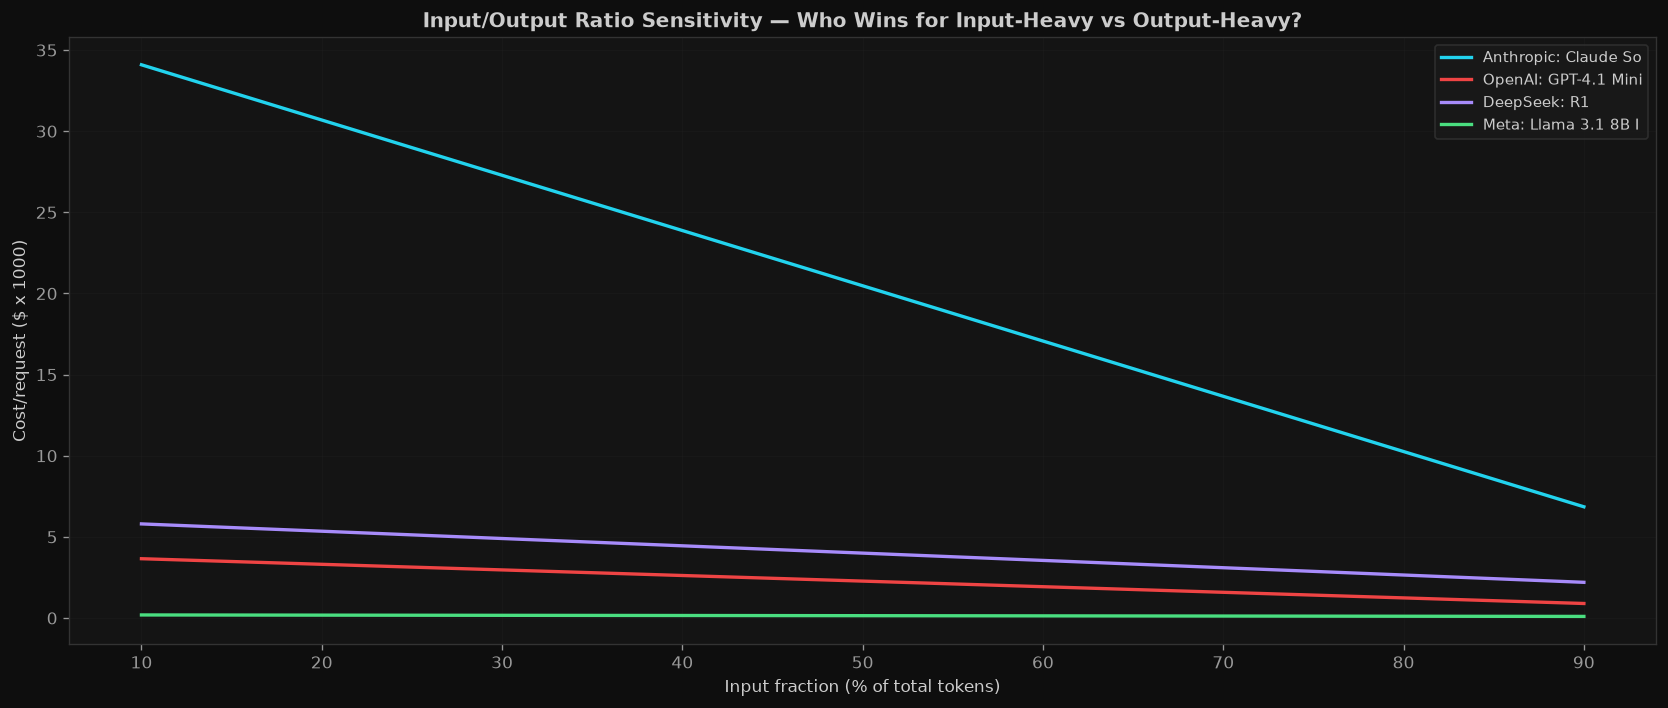

Key insight: models with expensive output tokens (Claude, GPT) get much
cheaper relative to others when the workload is input-heavy. Models with
symmetric pricing (Llama, DeepSeek) are less sensitive to the ratio.


In [6]:
# Sensitivity: vary input/output token ratio (total tokens fixed at 2500)
total_tok = 2500
io_ratios = np.arange(0.1, 0.95, 0.05)  # fraction that is input
cache_rate = 0.60  # moderate cache

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["#22d3ee", "#ef4444", "#a78bfa", "#4ade80"]

for j, (_, model) in enumerate(test_models.iterrows()):
    costs_by_ratio = []
    for r in io_ratios:
        i_tok = int(total_tok * r)
        o_tok = total_tok - i_tok
        costs_by_ratio.append(request_cost(model, i_tok, o_tok, cache_rate))

    short = model["name"][:20]
    ax.plot(io_ratios * 100, np.array(costs_by_ratio) * 1000,
            linewidth=2, color=colors[j % len(colors)], label=short)

ax.set_xlabel("Input fraction (% of total tokens)", fontsize=10)
ax.set_ylabel("Cost/request ($ x 1000)", fontsize=10)
ax.set_title("Input/Output Ratio Sensitivity — Who Wins for Input-Heavy vs Output-Heavy?",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key insight: models with expensive output tokens (Claude, GPT) get much")
print("cheaper relative to others when the workload is input-heavy. Models with")
print("symmetric pricing (Llama, DeepSeek) are less sensitive to the ratio.")


## 6. Cache pricing — the dimension OR hides

How common is cache pricing? What are the discount rates? Which models benefit
most from caching? This determines whether the cache column deserves prominent
placement on the Exchange page.


Models with cache read pricing: 300 / 438 (68%)
Models with cache write pricing: 96



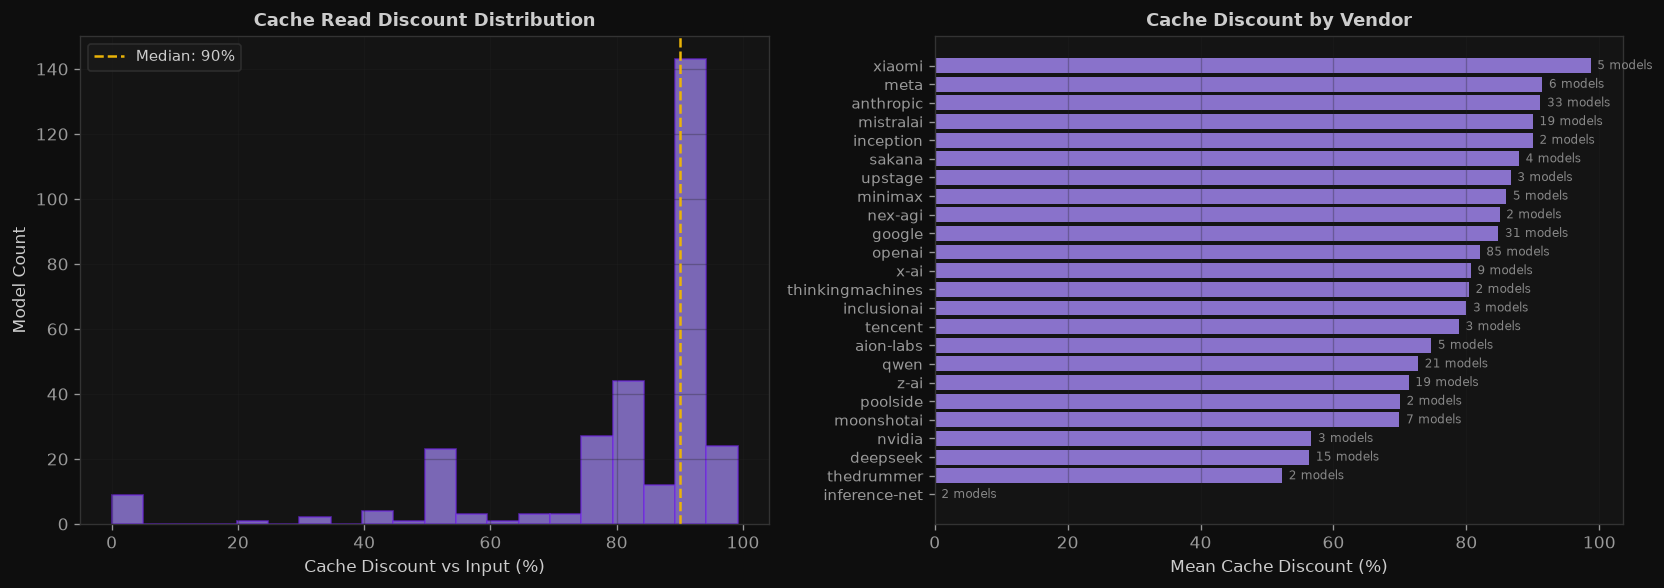


Median cache discount: 90%
Mean cache discount: 80%
75th percentile: 90%
Models with >= 50% cache discount: 283 (94%)


In [7]:
cached = df[df["has_cache"]].copy()
print(f"Models with cache read pricing: {len(cached)} / {len(df)} ({len(cached)/len(df):.0%})")
print(f"Models with cache write pricing: {(df['p_cache_write'] > 0).sum()}")
print()

# Cache discount distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

disc = cached["cache_disc"]
ax1.hist(disc * 100, bins=20, color="#a78bfa", alpha=0.7, edgecolor="#6d28d9")
ax1.set_xlabel("Cache Discount vs Input (%)")
ax1.set_ylabel("Model Count")
ax1.set_title("Cache Read Discount Distribution", fontsize=11, fontweight="bold")
ax1.axvline(disc.median() * 100, color="#eab308", linestyle="--",
            label=f"Median: {disc.median():.0%}")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Cache discount by vendor
vendor_disc = cached.groupby("vendor")["cache_disc"].agg(["mean", "count"]).sort_values("mean", ascending=False)
vendor_disc = vendor_disc[vendor_disc["count"] >= 2]  # vendors with 2+ models
ax2.barh(range(len(vendor_disc)), vendor_disc["mean"] * 100, color="#a78bfa", alpha=0.8)
ax2.set_yticks(range(len(vendor_disc)))
ax2.set_yticklabels(vendor_disc.index, fontsize=9)
ax2.set_xlabel("Mean Cache Discount (%)")
ax2.set_title("Cache Discount by Vendor", fontsize=11, fontweight="bold")
ax2.grid(True, axis="x", alpha=0.3)
ax2.invert_yaxis()

for k, (_, row) in enumerate(vendor_disc.iterrows()):
    ax2.text(row["mean"] * 100 + 1, k, f"{row['count']:.0f} models", fontsize=7, va="center", color="#888")

plt.tight_layout()
plt.show()

print(f"\nMedian cache discount: {disc.median():.0%}")
print(f"Mean cache discount: {disc.mean():.0%}")
print(f"75th percentile: {disc.quantile(0.75):.0%}")
print(f"Models with >= 50% cache discount: {(disc >= 0.5).sum()} ({(disc >= 0.5).mean():.0%})")


## 7. Findings — what the Exchange page should show

### What dimensions actually matter for the routing decision?

Based on the analysis above:

1. **Output price** — still the dominant cost component for most workloads.
   Must be primary sort/display.

2. **Cache read price** — this is the hidden dimension. Most models (check the
   percentage above) have cache pricing, and the median discount is large.
   For high-cache workloads (chatbot, agent), this can shift rankings
   significantly. **Must be prominently displayed.**

3. **Input price** — matters for RAG/long-context workloads where cache rates
   are low. Less important for chatbot/agent.

4. **Cache write price** — only a few vendors charge this (Anthropic, Google).
   It's a gotcha for consumers who don't know about it, but it doesn't affect
   the per-request steady-state cost (only the first request in a session).
   **Should be visible but secondary.**

5. **Quality scores** — intelligence_index is available for a subset of models.
   It's the only way to compare across model families. Without it, the
   Exchange is just a price table — with it, it's a marketplace that helps
   consumers find the right quality-price tradeoff. **Must be shown when
   available.**

6. **Effective cost** — the single number that incorporates workload shape +
   all pricing dimensions. This is what consumers should sort by.
   **This should be the primary column, not output price.**

### What the Exchange page should NOT do:

- Pretend to be a financial order book. There's no bid side, no continuous
  matching, and most models have 1-3 providers (not deep liquidity).
- Show "depth of market" bars when there are 3 rows.
- Mix same-model offers with alternative-model offers in one ranked list
  without clear separation.
- Show benchmark scores without explaining what they mean and where they
  come from.


In [8]:
# Final summary: the data that should drive the Exchange page
print("=" * 70)
print("DATA AVAILABILITY SUMMARY")
print("=" * 70)
print(f"Total models with pricing:              {len(df)}")
print(f"With cache read pricing:                {df['has_cache'].sum()} ({df['has_cache'].mean():.0%})")
print(f"With cache write pricing:               {(df['p_cache_write'] > 0).sum()}")
print(f"With intelligence index:                {df['has_bench'].sum()} ({df['has_bench'].mean():.0%})")
print(f"With coding index:                      {df['coding_idx'].notna().sum()}")
print(f"With agentic index:                     {df['agentic_idx'].notna().sum()}")
print(f"With reasoning pricing:                 {(df['p_reasoning'] > 0).sum()}")
print(f"Median cache discount (where avail):    {df.loc[df['has_cache'], 'cache_disc'].median():.0%}")
print()
print("WORKLOAD COST RANGES (cheapest → most expensive):")
for wl_name in WORKLOADS:
    sub = costs[costs["workload"] == wl_name]
    print(f"  {wl_name:20s}  ${sub['cost'].min():.6f} → ${sub['cost'].max():.4f}")
print()
print("PARETO FRONTIER SIZES:")
for wl_name, wl in WORKLOADS.items():
    qcol = {"intel": "intel_idx", "coding": "coding_idx", "agentic": "agentic_idx"}[wl["quality_floor"]]
    sub = costs[costs["workload"] == wl_name]
    front = pareto_frontier(sub, "cost", qcol)
    print(f"  {wl_name:20s}  {len(front)} models on frontier (of {sub[qcol].notna().sum()} with data)")
print("=" * 70)


DATA AVAILABILITY SUMMARY
Total models with pricing:              438
With cache read pricing:                300 (68%)
With cache write pricing:               96
With intelligence index:                136 (31%)
With coding index:                      167
With agentic index:                     130
With reasoning pricing:                 31
Median cache discount (where avail):    90%

WORKLOAD COST RANGES (cheapest → most expensive):
  Chatbot               $0.000041 → $0.5400
  Code assistant        $0.000093 → $1.0800
  RAG pipeline          $0.000123 → $1.0800
  Agent loop            $0.000032 → $0.5700

PARETO FRONTIER SIZES:
  Chatbot               6 models on frontier (of 136 with data)
  Code assistant        7 models on frontier (of 167 with data)
  RAG pipeline          9 models on frontier (of 136 with data)
  Agent loop            6 models on frontier (of 130 with data)
